# Federated Partitioning — FL-IDS Pipeline

**Project:** Evaluating Federated Learning for Intrusion Detection in Industrial IoT  
**Input:** `data/processed/datasense_preprocessed.csv` (from preprocessing notebook)  
**Output:** JSON partition files in `data/partitions/`  

---

## What This Notebook Does

This notebook creates and saves all the federated data partitions needed for the experiment
matrix. Instead of copying data per client, we save **row indices** — at experiment time,
we load the full dataset and slice each client's portion using these indices.

## Partitioning Strategies

| Strategy | Description | Purpose |
|----------|-------------|--------|
| **IID** | Stratified random split — each client mirrors the global class distribution | FL "easy mode" baseline |
| **Non-IID (label skew 0.7)** | Each client has one dominant attack class (~70% of their data) | Moderate heterogeneity |
| **Non-IID (label skew 0.9)** | Each client has one dominant attack class (~90% of their data) | Severe heterogeneity |

## Experiment Grid

Each strategy is generated for:
- **K ∈ {5, 10}** — number of clients
- **Seeds ∈ {42, 123, 456}** — 3 seeds for statistical robustness

That gives us **3 strategies × 2 K values × 3 seeds = 18 partition files**.

---
## Step 0 — Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import json
import os
import sys

# ── Add src/ to path so we can import our modules ─────────────────
sys.path.insert(0, os.path.abspath('../src/'))

from partitioning import (
    partition_iid,
    partition_noniid_label_skew,
    save_partition,
    load_partition,
    summarize_partition,
)

# ── Paths ──────────────────────────────────────────────────────────
DATA_PATH      = "../data/processed/datasense_preprocessed.csv"
PARTITION_DIR  = "../data/partitions/"
LABEL_CFG_PATH = "../data/processed/label_config.json"

os.makedirs(PARTITION_DIR, exist_ok=True)

print("Configuration ready.")

Configuration ready.


---
## Step 1 — Load Preprocessed Data

We only need two columns from the preprocessed CSV:
- `attack_category` — the integer-encoded 8-class label (used to create class-aware splits)
- `device_name` — preserved for potential device-based partitioning analysis

The feature columns aren't needed here — partitioning operates purely on indices and labels.

In [2]:
df = pd.read_csv(DATA_PATH)
labels = df['attack_category'].values
device_names = df['device_name'].values

print(f"Dataset: {len(labels):,} samples")
print(f"Classes: {len(np.unique(labels))} (labels 0–{np.max(labels)})")
print(f"Devices: {len(np.unique(device_names))}")

# ── Load label names for readable output ──────────────────────────
label_names = None
if os.path.exists(LABEL_CFG_PATH):
    with open(LABEL_CFG_PATH, 'r') as f:
        label_cfg = json.load(f)
    label_names = {int(k): v for k, v in label_cfg['label_mapping'].items()}
    print(f"\nLabel mapping: {label_names}")

print(f"\nGlobal class distribution:")
for c in sorted(np.unique(labels)):
    name = label_names.get(c, str(c)) if label_names else str(c)
    count = (labels == c).sum()
    pct = count / len(labels) * 100
    print(f"  {c} ({name:15s}): {count:>6,} samples ({pct:5.2f}%)")

Dataset: 30,030 samples
Classes: 8 (labels 0–7)
Devices: 38

Label mapping: {0: 'benign', 1: 'bruteforce', 2: 'ddos', 3: 'dos', 4: 'malware', 5: 'mitm', 6: 'recon', 7: 'web'}

Global class distribution:
  0 (benign         ): 13,680 samples (45.55%)
  1 (bruteforce     ):    364 samples ( 1.21%)
  2 (ddos           ):  3,234 samples (10.77%)
  3 (dos            ):  3,280 samples (10.92%)
  4 (malware        ):  1,444 samples ( 4.81%)
  5 (mitm           ):  1,471 samples ( 4.90%)
  6 (recon          ):  6,005 samples (20.00%)
  7 (web            ):    552 samples ( 1.84%)


---
## Step 2 — Generate All Partitions

This is the main loop. For each combination of strategy, K, and seed, we:
1. Run the partitioning function to get `client_id → [row_indices]`
2. Save to JSON with full metadata for reproducibility

### File naming convention
```
data/partitions/{strategy}_K{num_clients}_seed{seed}.json
```
Examples:
- `iid_K5_seed42.json`
- `noniid_label_skew_07_K10_seed123.json`
- `noniid_label_skew_09_K5_seed456.json`

In [3]:
# ── Define the experiment grid ────────────────────────────────────
# Each entry: (strategy_name, partition_function, extra_kwargs)

STRATEGIES = [
    ("iid",                      partition_iid,                {}),
    ("noniid_label_skew_07",     partition_noniid_label_skew,  {"dominant_fraction": 0.7}),
    ("noniid_label_skew_09",     partition_noniid_label_skew,  {"dominant_fraction": 0.9}),
]

K_VALUES = [5, 10]
SEEDS    = [42, 123, 456]

total_partitions = len(STRATEGIES) * len(K_VALUES) * len(SEEDS)
print(f"Generating {total_partitions} partition files...")
print(f"  Strategies: {[s[0] for s in STRATEGIES]}")
print(f"  K values:   {K_VALUES}")
print(f"  Seeds:      {SEEDS}")
print()

Generating 18 partition files...
  Strategies: ['iid', 'noniid_label_skew_07', 'noniid_label_skew_09']
  K values:   [5, 10]
  Seeds:      [42, 123, 456]



In [4]:
# ── Generate and save all partitions ──────────────────────────────
partition_files = []

for strategy_name, partition_func, kwargs in STRATEGIES:
    print(f"\n{'═' * 60}")
    print(f"Strategy: {strategy_name}")
    print(f"{'═' * 60}")

    for K in K_VALUES:
        for seed in SEEDS:
            # Run the partitioning algorithm
            client_indices = partition_func(
                labels,
                num_clients=K,
                seed=seed,
                **kwargs
            )

            # Build metadata for reproducibility
            metadata = {
                "strategy":      strategy_name,
                "num_clients":   K,
                "seed":          seed,
                "total_samples": len(labels),
                **kwargs  # includes dominant_fraction for non-IID
            }

            # Save
            filename = f"{strategy_name}_K{K}_seed{seed}.json"
            filepath = os.path.join(PARTITION_DIR, filename)
            save_partition(client_indices, metadata, filepath)
            partition_files.append(filepath)

print(f"\n\nDone! Generated {len(partition_files)} partition files.")


════════════════════════════════════════════════════════════
Strategy: iid
════════════════════════════════════════════════════════════
  Saved: iid_K5_seed42.json  (5 clients, 30,030 total samples)
  Saved: iid_K5_seed123.json  (5 clients, 30,030 total samples)
  Saved: iid_K5_seed456.json  (5 clients, 30,030 total samples)
  Saved: iid_K10_seed42.json  (10 clients, 30,030 total samples)
  Saved: iid_K10_seed123.json  (10 clients, 30,030 total samples)
  Saved: iid_K10_seed456.json  (10 clients, 30,030 total samples)

════════════════════════════════════════════════════════════
Strategy: noniid_label_skew_07
════════════════════════════════════════════════════════════
  Saved: noniid_label_skew_07_K5_seed42.json  (5 clients, 30,030 total samples)
  Saved: noniid_label_skew_07_K5_seed123.json  (5 clients, 30,030 total samples)
  Saved: noniid_label_skew_07_K5_seed456.json  (5 clients, 30,030 total samples)
  Saved: noniid_label_skew_07_K10_seed42.json  (10 clients, 30,030 total sample

---
## Step 3 — Verify Partitions: IID

For IID partitions, every client should have roughly the same class distribution as the
global dataset. The percentages per class should be nearly identical across all clients.

Let's inspect K=5 with seed=42 as a representative example.

In [5]:
# ── Load and inspect IID partition ────────────────────────────────
iid_path = os.path.join(PARTITION_DIR, "iid_K5_seed42.json")
iid_indices, iid_meta = load_partition(iid_path)

print(f"Strategy: {iid_meta['strategy']}")
print(f"Clients:  {iid_meta['num_clients']}")
print(f"Seed:     {iid_meta['seed']}")

summarize_partition(iid_indices, labels, label_names)

Strategy: iid
Clients:  5
Seed:     42

Client      Samples     benign brutefor     ddos      dos  malware     mitm    recon      web
────────────────────────────────────────────────────────────────────────────────────────────
  0            6008      45.5%     1.2%    10.8%    10.9%     4.8%     4.9%    20.0%     1.8%
  1            6007      45.5%     1.2%    10.8%    10.9%     4.8%     4.9%    20.0%     1.8%
  2            6006      45.6%     1.2%    10.8%    10.9%     4.8%     4.9%    20.0%     1.8%
  3            6006      45.6%     1.2%    10.8%    10.9%     4.8%     4.9%    20.0%     1.8%
  4            6003      45.6%     1.2%    10.8%    10.9%     4.8%     4.9%    20.0%     1.8%
────────────────────────────────────────────────────────────────────────────────────────────
  TOTAL       30030


In [6]:
# ── Sanity checks ─────────────────────────────────────────────────
# 1. No sample appears in more than one client
all_iid_indices = []
for k, idxs in iid_indices.items():
    all_iid_indices.extend(idxs)

assert len(all_iid_indices) == len(set(all_iid_indices)), \
    "DUPLICATE INDICES FOUND — a sample is assigned to multiple clients!"

# 2. All samples are accounted for
assert len(all_iid_indices) == len(labels), \
    f"MISSING SAMPLES — {len(labels) - len(all_iid_indices)} samples unassigned!"

print("Sanity checks passed:")
print(f"  No duplicate indices ✓")
print(f"  All {len(labels):,} samples accounted for ✓")

Sanity checks passed:
  No duplicate indices ✓
  All 30,030 samples accounted for ✓


---
## Step 4 — Verify Partitions: Non-IID (Label Skew 0.7)

For non-IID with `dominant_fraction=0.7`, each client should have one class that makes
up a disproportionately large share of their data. The dominant class cycles through
the 8 attack categories, so with K=5 clients, the first 5 classes each dominate one client.

You should see one high percentage per row, with the rest being small.

In [7]:
# ── Load and inspect Non-IID 0.7 partition ────────────────────────
noniid07_path = os.path.join(PARTITION_DIR, "noniid_label_skew_07_K5_seed42.json")
noniid07_indices, noniid07_meta = load_partition(noniid07_path)

print(f"Strategy:          {noniid07_meta['strategy']}")
print(f"Clients:           {noniid07_meta['num_clients']}")
print(f"Dominant fraction: {noniid07_meta.get('dominant_fraction', 'N/A')}")
print(f"Seed:              {noniid07_meta['seed']}")

summarize_partition(noniid07_indices, labels, label_names)

Strategy:          noniid_label_skew_07
Clients:           5
Dominant fraction: 0.7
Seed:              42

Client      Samples     benign brutefor     ddos      dos  malware     mitm    recon      web
────────────────────────────────────────────────────────────────────────────────────────────
  0           11809      81.1%     0.2%     2.1%     2.1%     0.9%     2.5%    10.2%     0.9%
  1            3484      29.4%     7.3%     7.0%     7.1%     3.1%     8.4%    34.5%     3.2%
  2            5276      19.4%     0.5%    42.9%     4.7%     2.0%     5.6%    22.8%     2.1%
  3            5305      19.3%     0.5%     4.6%    43.3%     2.0%     5.5%    22.6%     2.1%
  4            4156      24.7%     0.6%     5.8%     5.9%    24.3%     7.1%    28.9%     2.6%
────────────────────────────────────────────────────────────────────────────────────────────
  TOTAL       30030


In [ ]:
# ── Sanity checks for non-IID 0.7 ────────────────────────────────
all_noniid07 = []
for k, idxs in noniid07_indices.items():
    all_noniid07.extend(idxs)

assert len(all_noniid07) == len(set(all_noniid07)), "DUPLICATE INDICES!"
assert len(all_noniid07) == len(labels), "MISSING SAMPLES!"
print("Sanity checks passed ✓")

30030
30030
Sanity checks passed ✓


---
## Step 5 — Verify Partitions: Non-IID (Label Skew 0.9)

With `dominant_fraction=0.9`, the skew is much more extreme. Each client's dominant
class should make up an even larger share. This simulates the hardest scenario for
FedAvg — local gradients are highly divergent.

In [9]:
# ── Load and inspect Non-IID 0.9 partition ────────────────────────
noniid09_path = os.path.join(PARTITION_DIR, "noniid_label_skew_09_K5_seed42.json")
noniid09_indices, noniid09_meta = load_partition(noniid09_path)

print(f"Strategy:          {noniid09_meta['strategy']}")
print(f"Dominant fraction: {noniid09_meta.get('dominant_fraction', 'N/A')}")

summarize_partition(noniid09_indices, labels, label_names)

Strategy:          noniid_label_skew_09
Dominant fraction: 0.9

Client      Samples     benign brutefor     ddos      dos  malware     mitm    recon      web
────────────────────────────────────────────────────────────────────────────────────────────
  0           14129      87.1%     0.1%     0.6%     0.6%     0.3%     2.1%     8.5%     0.8%
  1            2474      13.8%    13.2%     3.3%     3.3%     1.5%    11.9%    48.5%     4.5%
  2            4984       6.9%     0.2%    58.4%     1.6%     0.7%     5.9%    24.1%     2.2%
  3            5025       6.8%     0.2%     1.6%    58.7%     0.7%     5.9%    23.9%     2.2%
  4            3418      10.0%     0.3%     2.4%     2.4%    38.0%     8.6%    35.1%     3.2%
────────────────────────────────────────────────────────────────────────────────────────────
  TOTAL       30030


In [10]:
# ── Sanity checks for non-IID 0.9 ────────────────────────────────
all_noniid09 = []
for k, idxs in noniid09_indices.items():
    all_noniid09.extend(idxs)

assert len(all_noniid09) == len(set(all_noniid09)), "DUPLICATE INDICES!"
assert len(all_noniid09) == len(labels), "MISSING SAMPLES!"
print("Sanity checks passed ✓")

Sanity checks passed ✓


---
## Step 6 — Visual Comparison: IID vs Non-IID Distributions

A side-by-side heatmap showing how class distributions differ across clients
under each strategy. This is a good figure for your thesis report — it visually
demonstrates the heterogeneity you're testing against.

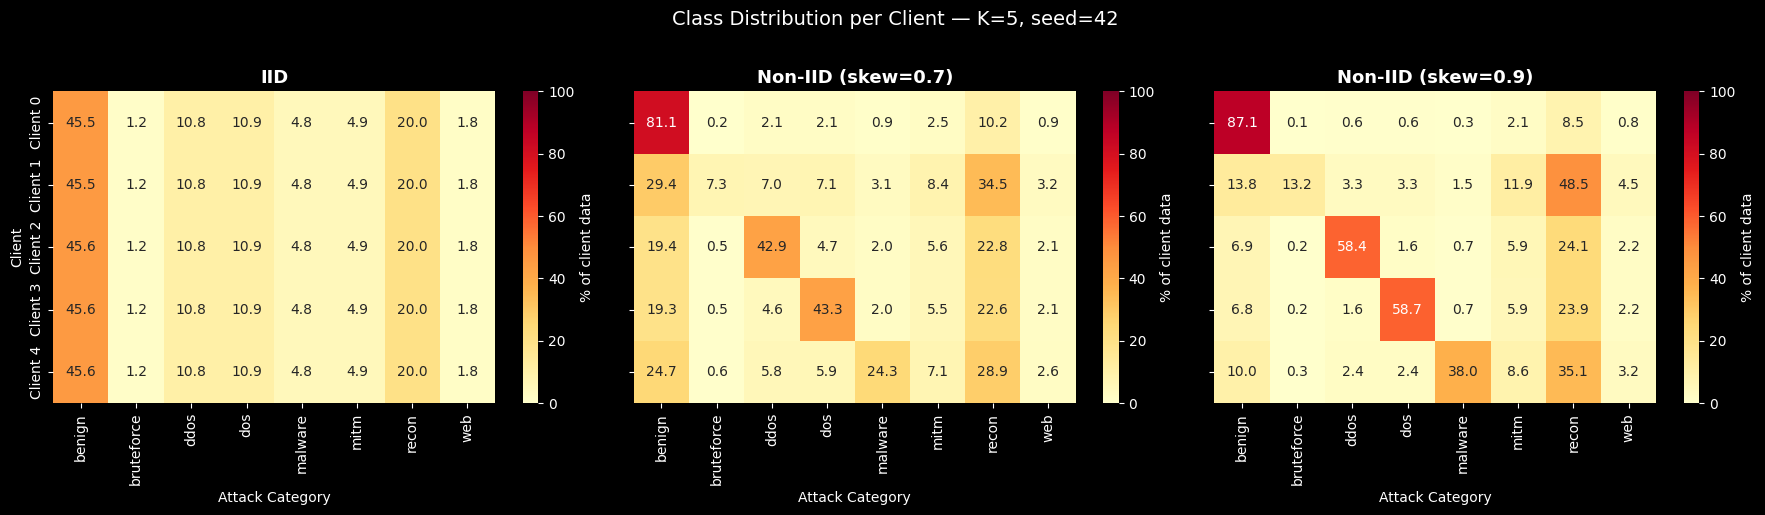

Figure saved to results/partition_distributions_K5.png


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


def build_distribution_matrix(client_indices, labels, n_classes=8):
    """
    Build a (num_clients × n_classes) matrix of class percentages.
    """
    n_clients = len(client_indices)
    matrix = np.zeros((n_clients, n_classes))
    for k in sorted(client_indices.keys()):
        idxs = client_indices[k]
        client_labels = labels[idxs]
        counts = np.bincount(client_labels, minlength=n_classes)
        matrix[k] = counts / counts.sum() * 100
    return matrix


# ── Build matrices for K=5, seed=42 ───────────────────────────────
mat_iid      = build_distribution_matrix(iid_indices, labels)
mat_noniid07 = build_distribution_matrix(noniid07_indices, labels)
mat_noniid09 = build_distribution_matrix(noniid09_indices, labels)

# ── Class labels for axis ─────────────────────────────────────────
class_labels = [label_names.get(c, str(c)) for c in range(8)] if label_names else [str(c) for c in range(8)]

# ── Plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, mat, title in zip(axes, 
                          [mat_iid, mat_noniid07, mat_noniid09],
                          ['IID', 'Non-IID (skew=0.7)', 'Non-IID (skew=0.9)']):
    sns.heatmap(mat, ax=ax, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=class_labels,
                yticklabels=[f'Client {k}' for k in range(mat.shape[0])],
                vmin=0, vmax=100, cbar_kws={'label': '% of client data'})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Attack Category')
    if ax == axes[0]:
        ax.set_ylabel('Client')

plt.suptitle('Class Distribution per Client — K=5, seed=42', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/partition_distributions_K5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to results/partition_distributions_K5.png")

---
## Step 7 — Verify K=10 Partition (Spot Check)

Quick verification that K=10 partitions also work correctly. With 10 clients and
8 classes, clients 8 and 9 will cycle back to the dominant classes of clients 0 and 1.

In [12]:
# ── Load K=10 non-IID 0.7 ─────────────────────────────────────────
noniid07_k10_path = os.path.join(PARTITION_DIR, "noniid_label_skew_07_K10_seed42.json")
noniid07_k10_indices, noniid07_k10_meta = load_partition(noniid07_k10_path)

print(f"Strategy: {noniid07_k10_meta['strategy']}, K={noniid07_k10_meta['num_clients']}")
summarize_partition(noniid07_k10_indices, labels, label_names)

# ── Sanity check ──────────────────────────────────────────────────
all_k10 = []
for k, idxs in noniid07_k10_indices.items():
    all_k10.extend(idxs)
assert len(all_k10) == len(set(all_k10)), "DUPLICATE INDICES!"
assert len(all_k10) == len(labels), "MISSING SAMPLES!"
print("\nSanity checks passed ✓")

Strategy: noniid_label_skew_07, K=10

Client      Samples     benign brutefor     ddos      dos  malware     mitm    recon      web
────────────────────────────────────────────────────────────────────────────────────────────
  0            5339      89.7%     0.3%     2.0%     2.1%     0.9%     0.9%     3.8%     0.4%
  1            1176      43.6%    10.8%     9.2%     9.4%     4.2%     4.2%    17.1%     1.6%
  2            3216      16.0%     0.4%    70.4%     3.4%     1.5%     1.5%     6.2%     0.6%
  3            3247      15.8%     0.4%     3.3%    70.7%     1.5%     1.5%     6.2%     0.6%
  4            2021      25.4%     0.7%     5.3%     5.4%    50.0%     2.4%     9.9%     0.9%
  5            2039      25.2%     0.7%     5.3%     5.3%     2.4%    50.5%     9.8%     0.9%
  6            5062      10.1%     0.3%     2.1%     2.2%     0.9%     1.0%    83.0%     0.4%
  7            1426      36.0%     0.9%     7.6%     7.6%     3.4%     3.4%    14.0%    27.1%
  8            5333    

---
## Step 8 — List All Generated Partition Files

In [13]:
# ── List all partition files with their metadata ───────────────────
print(f"All partition files in {PARTITION_DIR}:")
print(f"{'─' * 70}")

files = sorted([f for f in os.listdir(PARTITION_DIR) if f.endswith('.json')])
for f in files:
    fpath = os.path.join(PARTITION_DIR, f)
    _, meta = load_partition(fpath)
    skew_info = f", dom_frac={meta.get('dominant_fraction', '')}" \
                if 'dominant_fraction' in meta else ""
    print(f"  {f:45s}  K={meta['num_clients']}, seed={meta['seed']}{skew_info}")

print(f"\nTotal: {len(files)} partition files")

All partition files in ../data/partitions/:
──────────────────────────────────────────────────────────────────────
  iid_K10_seed123.json                           K=10, seed=123
  iid_K10_seed42.json                            K=10, seed=42
  iid_K10_seed456.json                           K=10, seed=456
  iid_K5_seed123.json                            K=5, seed=123
  iid_K5_seed42.json                             K=5, seed=42
  iid_K5_seed456.json                            K=5, seed=456
  noniid_label_skew_07_K10_seed123.json          K=10, seed=123, dom_frac=0.7
  noniid_label_skew_07_K10_seed42.json           K=10, seed=42, dom_frac=0.7
  noniid_label_skew_07_K10_seed456.json          K=10, seed=456, dom_frac=0.7
  noniid_label_skew_07_K5_seed123.json           K=5, seed=123, dom_frac=0.7
  noniid_label_skew_07_K5_seed42.json            K=5, seed=42, dom_frac=0.7
  noniid_label_skew_07_K5_seed456.json           K=5, seed=456, dom_frac=0.7
  noniid_label_skew_09_K10_seed123.json    

---
## Step 9 — How to Use Partitions at Experiment Time

This cell demonstrates the pattern your `federated.py` and `baselines.py` will use
to load a partition and create per-client data views.

In [14]:
# ── Example: load a partition and create client data views ────────
from preprocessing import load_processed_data, apply_scaler

# 1. Load the full preprocessed dataset
X, y, device_names = load_processed_data(DATA_PATH)

# 2. Load a partition
client_indices, meta = load_partition(
    os.path.join(PARTITION_DIR, "noniid_label_skew_07_K5_seed42.json")
)

# 3. For each client, slice the data and apply scaling locally
print(f"Loaded partition: {meta['strategy']}, K={meta['num_clients']}\n")

for client_id in sorted(client_indices.keys()):
    idxs = client_indices[client_id]
    X_client = X[idxs]
    y_client = y[idxs]

    # In practice, you'd split into train/val here, then scale:
    # X_train, X_val, y_train, y_val = train_test_split(...)
    # X_train_scaled, X_val_scaled, scaler = apply_scaler(X_train, X_val)

    n_classes_present = len(np.unique(y_client))
    print(f"  Client {client_id}: {len(idxs):>5,} samples, "
          f"{n_classes_present}/8 classes present")

Loaded partition: noniid_label_skew_07, K=5

  Client 0: 11,809 samples, 8/8 classes present
  Client 1: 3,484 samples, 8/8 classes present
  Client 2: 5,276 samples, 8/8 classes present
  Client 3: 5,305 samples, 8/8 classes present
  Client 4: 4,156 samples, 8/8 classes present


---
## Summary

### What was done
1. Loaded the preprocessed dataset (30,030 samples, 8-class labels)
2. Generated 18 partition files across 3 strategies × 2 K values × 3 seeds
3. Verified correctness: no duplicate indices, all samples accounted for
4. Inspected class distributions for IID, non-IID 0.7, and non-IID 0.9
5. Created a heatmap visualization for the thesis report

### Output files
| Directory | Contents |
|-----------|----------|
| `data/partitions/` | 18 JSON files with partition indices + metadata |
| `results/` | `partition_distributions_K5.png` heatmap figure |

### Naming convention
```
{strategy}_K{num_clients}_seed{seed}.json
```

### Next step
→ **Model definition** (`model.py`): Define the feedforward neural network architecture,
then **federated training** (`federated.py`): Implement FedAvg with these partitions.